## Linear Regression

Task: do a linear regression

Our data are described by a linear function $ax+b$ plus some noise $n$

$$d_i = a + b x_i + n_i$$

$d_i$ are the measured values for some measuring point $x_i$.

The coefficiencts $a$ and $b$ are subsumed in a model vector

$${\bf m}=\begin{bmatrix}a\\b\end{bmatrix} = \begin{bmatrix}m_1\\m_2\end{bmatrix}$$

The forward operator is linear with respect to m and can be written as ${\bf A}{\bf m}={\bf d^{syn}}$ with
$$
{\bf A}=\begin{bmatrix}
1 & x_1\\
1 & x_2\\
\ldots & \ldots \\
1 & x_D
\end{bmatrix}$$

**Task**: Write a function that creates a matrix for a set of given $x$ values. Create one for a given $x$ vector and plot some examples.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def LinRegMatrix(x):
    """Create Linear Regression matrix."""
    A = np.ones((len(x), 2))
    A[:, 1] = x[:]
    return A

[ 0.53465933 -0.52341324]


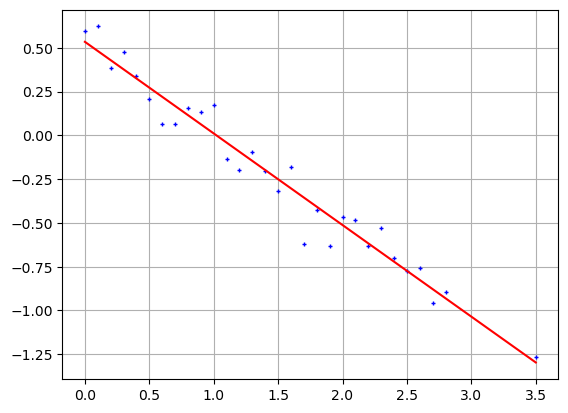

In [13]:
x = np.arange(0, 3, 0.1)
x[-1] = 3.5
error = 0.1
A = LinRegMatrix(x)
d = A @ np.array([0.5, -0.5]) + np.random.randn(len(x)) * error
# determine least-squares solution
# m = np.linalg.lstsq(A, d, rcond=None)[0] # or
Ainv = np.linalg.inv(A.T @ A) @ A.T
m = Ainv @ d
print(m)
plt.plot(x, d, "b+")
plt.plot(x, A@m, "r-")
plt.grid()

mean= 6.38378239159465e-17  std= 0.09863001487246403
mean= 6.439293542825908e-16  std= 0.9863001487246402


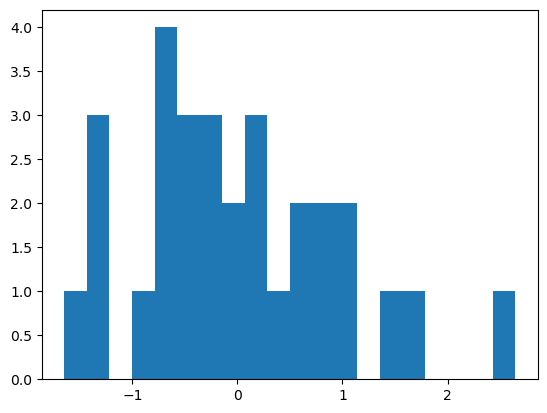

In [14]:
residual = A @ m - d
print("mean=", np.mean(residual), " std=", np.std(residual))
eresidual = residual / error
print("mean=", np.mean(eresidual), " std=", np.std(eresidual))
plt.hist(eresidual, bins=20);

### Lessons to be learned
1. The least-squares inversion minimizing the L2 norm is strongly connected to Gaussian statistics.
1. The error-weighted residual should (for large data numbers) show a Gaussian normal distribution (mean value of 0 and standard deviation of 1).
1. The misfit function should not show any systematics.

## Tasks for homework
1. Test with different values for the model and plot also the misfit $d-Am$
1. Increase the error level and look at the residual statistics.
1. Decrease or increase the number of measurements and watch statistics.
1. Test the same with common random noise instead of Gaussian noise.
1. Extend the matrix function to an arbitrary polynomial degree $P$

$$ y_i = \sum\limits_{j=0}^P a_{ij} x^j $$

(note the reversed order of coefficients)

1. Repeat the inversion by fitting a third-order polynomial.
1. Compute the singular value decomposition for different polynomial degrees.



In [15]:
RM = Ainv @ A
display(RM)

array([[1.00000000e+00, 2.22044605e-16],
       [1.38777878e-17, 1.00000000e+00]])

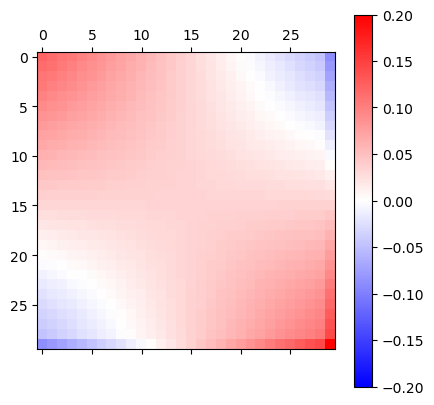

In [16]:
RD = A @ Ainv
im = plt.matshow(RD, vmin=-0.2, vmax=0.2, cmap="bwr")
plt.colorbar(im);

1.9999999999999993

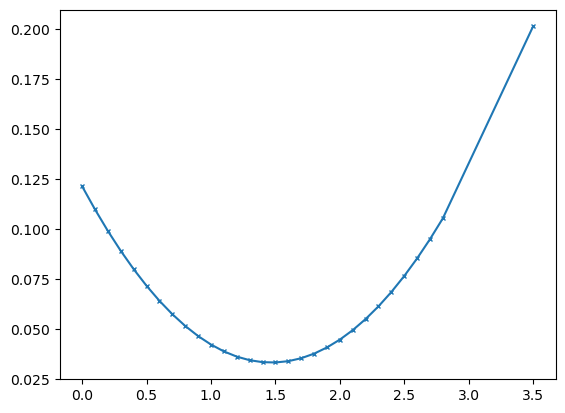

In [19]:
rd = np.diag(RD)
display(np.sum(rd))
plt.plot(x, rd, "x-");

**Lessons learned**

* the data importance matrix is symmetric
* the total importance is 2 (number of model parameters)
* the importance (influence on result) is growing towards the end members
* there is a positive correlation between neighboring data

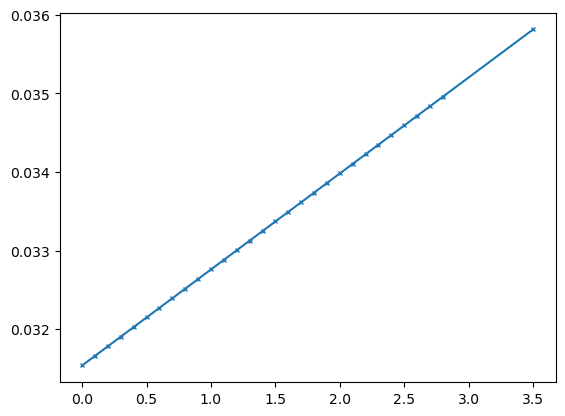

In [25]:
plt.plot(x, RD[15, :], "x-");

**Tasks**:

* switch to a non-equidistant discretization
* how does the data importance matrix change?
* introduce an error vector with a single higher and a single lower value
* how do the data importances change for these?